In [2]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler

# KMeans
from sklearn.cluster import KMeans

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
df = pd.read_csv('cousin-marriage-data.csv')

df.head()

,Country,Percent
0,Burkina Faso,65.8
1,Kuwait,51.7
2,Nigeria,51.2
3,Pakistan,51.0
4,Sudan,50.4


In [4]:
print(df.info())
print(df.describe())

# Check missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Country  70 non-null     str    
 1   Percent  70 non-null     float64
dtypes: float64(1), str(1)
memory usage: 1.7 KB
None
         Percent
count  70.000000
mean   16.304286
std    17.888969
min     0.100000
25%     0.950000
50%     4.950000
75%    31.450000
max    65.800000


Country    0
Percent    0
dtype: int64

In [6]:
if 'Marriage_Rate' in df.columns:
    df['Marriage_Rate'] = df['Marriage_Rate'].fillna(df['Marriage_Rate'].mean())

In [8]:
if 'Notes' in df.columns:
    df['Cleaned_Notes'] = df['Notes'].apply(preprocess_text)
else:
    print("Column 'Notes' not found. Available columns:", df.columns)

Column 'Notes' not found. Available columns: Index(['Country', 'Percent'], dtype='str')


In [11]:
print(df.columns)

Index(['Country', 'Percent'], dtype='str')


In [5]:
expected = ['Marriage_Rate', 'Year']
missing = [col for col in expected if col not in df.columns]

print("Missing columns:", missing)

Missing columns: ['Marriage_Rate', 'Year']


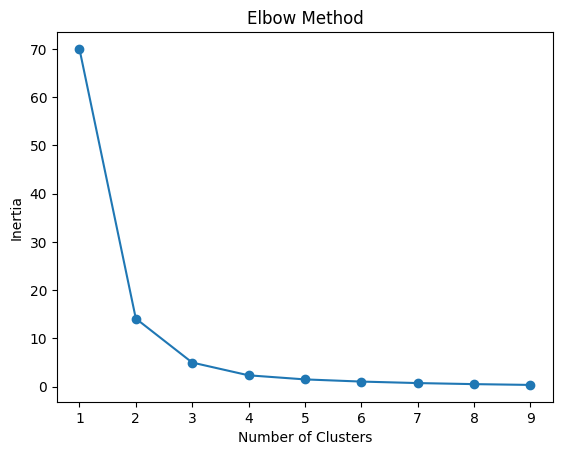

In [9]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. Define your dataset
X = df.select_dtypes(include=['number'])  # or df[['col1', 'col2']]

# 2. Scale data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)

# 3. Elbow method
inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

# 4. Plot
plt.plot(range(1, 10), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

In [10]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_data)

In [12]:
print(df.head())
print(df.columns)

        Country  Percent  Cluster
0  Burkina Faso     65.8        2
1        Kuwait     51.7        2
2       Nigeria     51.2        2
3      Pakistan     51.0        2
4         Sudan     50.4        2
Index(['Country', 'Percent', 'Cluster'], dtype='str')


In [13]:
df.groupby('Cluster').mean(numeric_only=True)

,Percent
Cluster,
0,28.369565
1,2.169231
2,50.525000


In [14]:
df.to_csv('clustered_cousin_marriage_data.csv', index=False)